<a href="https://colab.research.google.com/github/shreyaa-chax05/machine-learning/blob/dev/Feature_Scaling_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('/content/sample_data/Social_Network_Ads.csv')

In [6]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [7]:
df=df.iloc[:,2:]

In [8]:
df.sample(5)

,Age,EstimatedSalary,Purchased
244,41,72000,0
289,37,78000,1
132,30,87000,0
131,33,31000,0
85,31,118000,1


##Train Test Split

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)

In [10]:
x_train.shape,x_test.shape

((280, 2), (120, 2))

##StandardScaler

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
#fix the scaler to the train set,it will learn the parameters
scaler.fit(x_train)
#transform train and test sets
x_train_scaled=pd.DataFrame(scaler.transform(x_train))
x_test_scaled=pd.DataFrame(scaler.transform(x_test))

In [12]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [13]:
x_train_scaled

,0,1
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [14]:
np.round(x_train_scaled.describe(),1)

,0,1
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


##Effect of Scaling

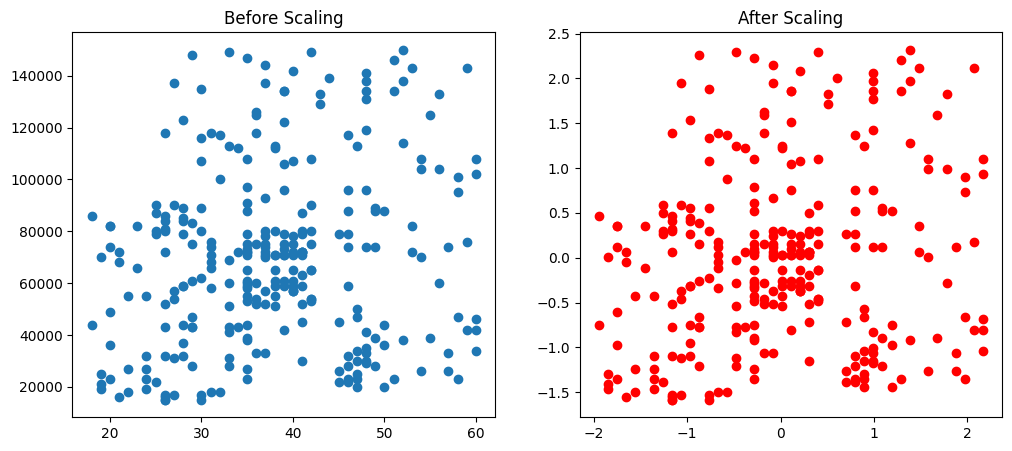

In [15]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(x_train['Age'],x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled.iloc[:,0],x_train_scaled.iloc[:,1],c='red')
ax2.set_title("After Scaling")
plt.show()

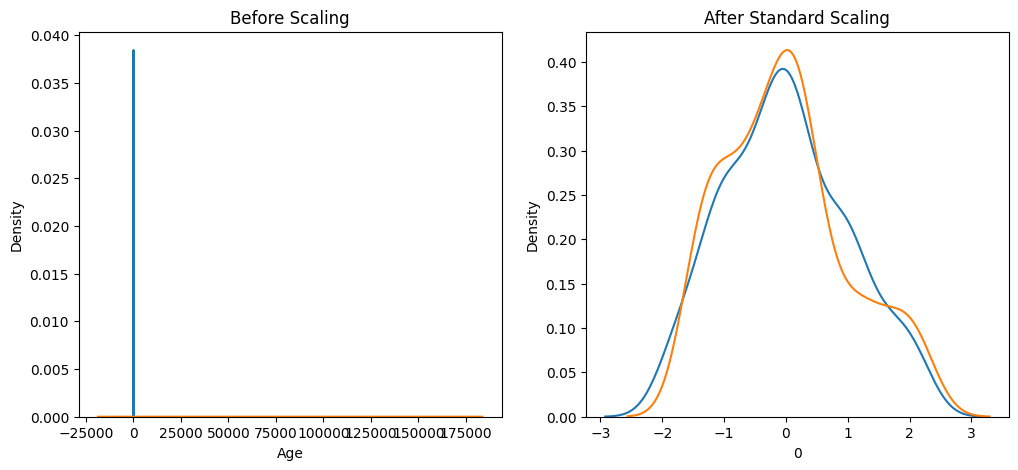

In [16]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
#before scaling
ax1.set_title("Before Scaling")
sns.kdeplot(x_train['Age'],ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'],ax=ax1)
#after scaling
ax2.set_title("After Standard Scaling")
sns.kdeplot(x_train_scaled.iloc[:,0],ax=ax2)
sns.kdeplot(x_train_scaled.iloc[:,1],ax=ax2)
plt.show()

##Comparision of Distribution

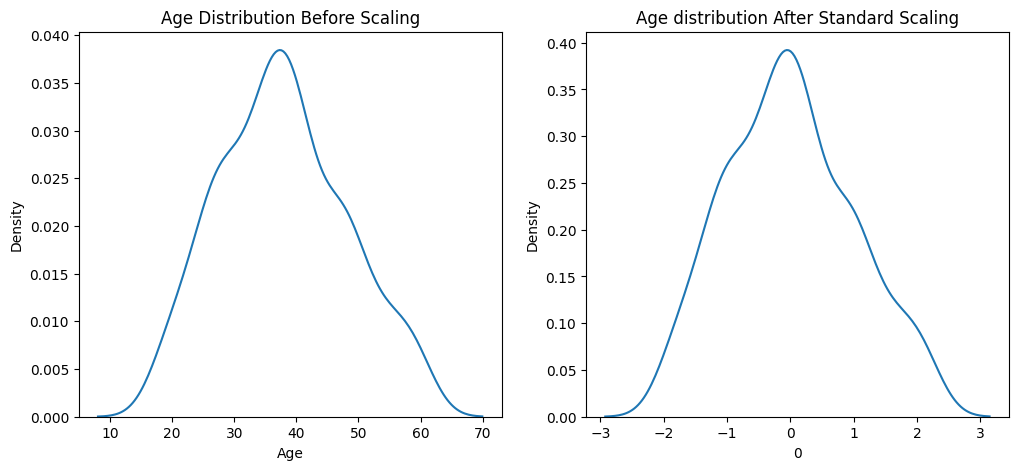

In [17]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
#before scaling
ax1.set_title("Age Distribution Before Scaling")
sns.kdeplot(x_train['Age'],ax=ax1)
#after scaling
ax2.set_title("Age distribution After Standard Scaling")
sns.kdeplot(x_train_scaled.iloc[:,0],ax=ax2)
plt.show()

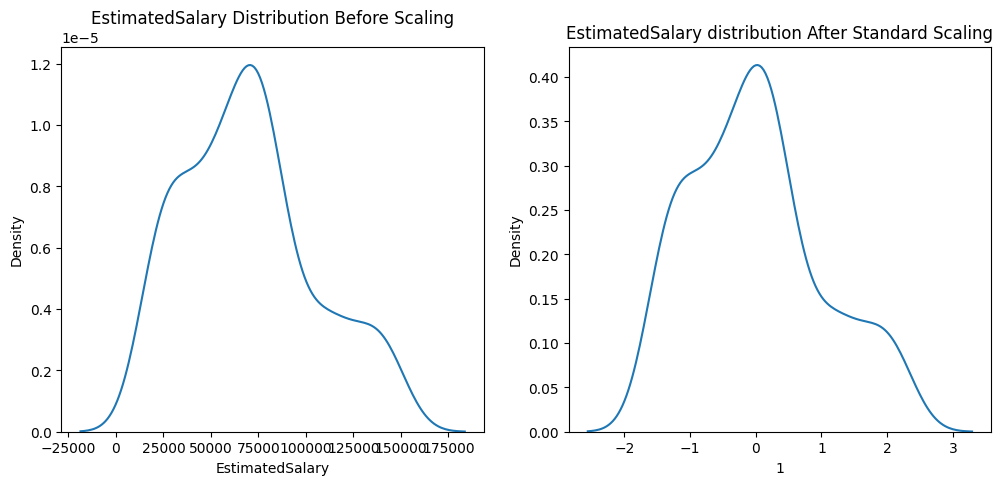

In [18]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
#before scaling
ax1.set_title("EstimatedSalary Distribution Before Scaling")
sns.kdeplot(x_train['EstimatedSalary'],ax=ax1)
#after scaling
ax2.set_title("EstimatedSalary distribution After Standard Scaling")
sns.kdeplot(x_train_scaled.iloc[:,1],ax=ax2)
plt.show()

##Why scaling is important?

In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [21]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

LogisticRegression()

In [22]:
y_pred=lr.predict(x_test)
y_pred_scaled=lr_scaled.predict(x_test_scaled)

In [23]:
from sklearn.metrics import accuracy_score

In [24]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


In [25]:
from sklearn.tree import DecisionTreeClassifier

In [26]:
dt=DecisionTreeClassifier()
dt_scaled=DecisionTreeClassifier()

In [27]:
dt.fit(x_train,y_train)
dt_scaled.fit(x_train_scaled,y_train)

DecisionTreeClassifier()

In [28]:
DecisionTreeClassifier()

DecisionTreeClassifier()

In [29]:
y_pred=dt.predict(x_test)
y_pred_scaled=dt_scaled.predict(x_train_scaled)

In [30]:
print("Actual",accuracy_score(y_test,y_pred))
y_pred_scaled=dt_scaled.predict(x_test_scaled)
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.875


In [31]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


##Effect of Outlier

In [32]:
df=pd.concat([df, pd.DataFrame({'Age':[5,90,95],'EstimatedSalary':[1000,250000,350000],'Purchased':[0,1,1]})], ignore_index=True)

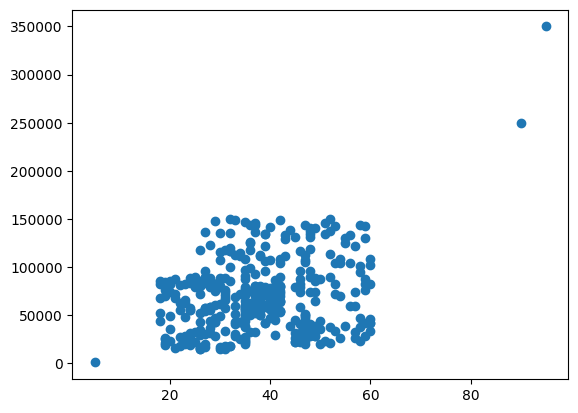

In [33]:
plt.scatter(df['Age'],df['EstimatedSalary'])

In [34]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)
x_train.shape,x_test.shape

((282, 2), (121, 2))

In [35]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
#fit the scaler to the train set, it will learn the parameters
scaler.fit(x_train)
#transform train and test sets
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [36]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

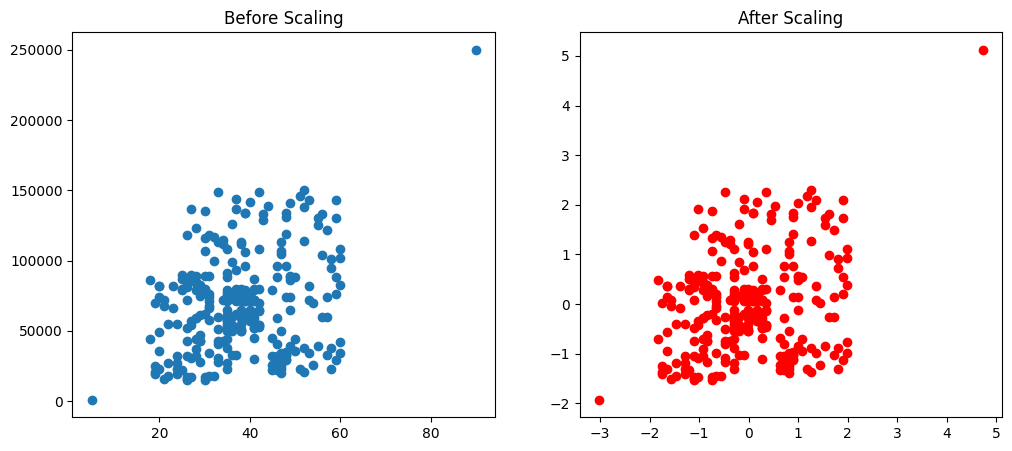

In [37]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(x_train['Age'],x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Age'],x_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()